`conda activate r_python`

# SCRAN normalization

Main source of code: https://github.com/theislab/scib-reproducibility/blob/main/notebooks/data_preprocessing/pancreas/02_normalize_human_pancreas.ipynb, also inspired by https://github.com/dpeerlab/spectra/blob/main/notebooks/scran_preprocessing.ipynb

This notebook performs the data normalization of the collection of DMG atlas data. This collection consists of the following data sets:

* Ruiz2023 (This study)
* Filbin2018 (GSE102130)
* Liu2022 (GSE184357)
* Jessa2022 (GSE188625/EGAS00001005773)

For all but 'Filbin2018' and 'Liu2022' datasets, we perform *scran* normalisation (these datasets are in TPM). Subsequently, we log-scale all data sets.

### Import packages

In [1]:
import sys

In [2]:
import anndata
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
import datetime
from scipy.sparse import csr_matrix, issparse

sc.logging.print_versions()
now = datetime.datetime.now()
today = now.strftime("%Y%m%d")

-----
anndata     0.8.0
scanpy      1.9.2
-----
PIL                 9.4.0
argcomplete         NA
asciitree           NA
asttokens           NA
backcall            0.2.0
beta_ufunc          NA
binom_ufunc         NA
cffi                1.15.1
cloudpickle         2.2.1
colorama            0.4.6
comm                0.1.2
cycler              0.10.0
cython_runtime      NA
cytoolz             0.12.0
dask                2023.1.1
dateutil            2.8.2
debugpy             1.6.6
decorator           5.1.1
defusedxml          0.7.1
entrypoints         0.4
executing           1.2.0
fasteners           0.17.3
h5py                3.8.0
hypergeom_ufunc     NA
igraph              0.10.4
invgauss_ufunc      NA
ipykernel           6.21.1
ipython_genutils    0.2.0
ipywidgets          8.0.4
jedi                0.18.2
jinja2              3.1.2
joblib              1.2.0
jupyter_server      2.2.1
kiwisolver          1.4.4
leidenalg           0.9.1
llvmlite            0.39.1
louvain             0.8.0
lz4  

In [3]:
sc.settings.verbosity = 3

In [4]:
sc.settings.n_jobs = 12

In [5]:
import rpy2.rinterface_lib.callbacks
import logging

from rpy2.robjects import pandas2ri
import anndata2ri

In [6]:
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

In [7]:
%%R
sessionInfo()

R version 4.2.2 (2022-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/libopenblasp-r0.3.21.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] tools     stats     graphics  grDevices utils     datasets  methods  
[8] base     

loaded via a namespace (and not attached):
[1] compiler_4.2.2


## Load data

In the following, import the `csv` files (created in R) to convert them into an `anndata` file.

In [8]:
path_dir = '../data/'

In [9]:
adata_all = sc.read(filename = path_dir + 'merged_dmg_atlas_filtered_no_doublets.h5ad')
adata_all

AnnData object with n_obs × n_vars = 548500 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sampl

In [10]:
print(f"Total number of cells: {adata_all.n_obs}")
adata = adata_all[(~adata_all.obs.outlier_3MAD) & (~adata_all.obs.mt_outlier) & (~adata_all.obs.ribo_outlier)].copy()
sc.pp.filter_cells(adata, min_genes=200)

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 548500
filtered out 29774 cells that have less than 200 genes expressed
Number of cells after filtering of low quality cells: 409561


In [11]:
del adata_all

In [12]:
# use .loc to select the row with the specified ID and modify the value of Batch_for_correction
# this to keep the Ruiz2023 sample together for normalization
adata.obs.loc[adata.obs['SampleID'] == 'GNG_region_11', 'Batch_for_correction'] = '10Xv3.1_nuclei_rna'

In [14]:
batch_value = adata.obs.loc[adata.obs['SampleID'] == 'GNG_region_11', 'Batch_for_correction'].values[0]
print(f"The new value of Batch_for_correction for GNG_region_11 is {batch_value}.")

The new value of Batch_for_correction for GNG_region_11 is 10Xv3.1_nuclei_rna.


In [15]:
adata.shape

(409561, 19248)

In [16]:
adata.X[0, :7].toarray()

array([[0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [17]:
print(adata.X)

  (1, 0)	5.0
  (5, 0)	1.0
  (18, 0)	2.0
  (47, 0)	1.0
  (78, 0)	1.0
  (108, 0)	1.0
  (109, 0)	1.0
  (156, 0)	1.0
  (159, 0)	1.0
  (165, 0)	1.0
  (173, 0)	1.0
  (247, 0)	1.0
  (265, 0)	1.0
  (299, 0)	1.0
  (311, 0)	1.0
  (329, 0)	1.0
  (346, 0)	1.0
  (369, 0)	1.0
  (383, 0)	1.0
  (385, 0)	1.0
  (415, 0)	1.0
  (441, 0)	1.0
  (445, 0)	1.0
  (462, 0)	1.0
  (546, 0)	1.0
  :	:
  (408687, 19247)	1.0
  (408690, 19247)	1.0
  (408773, 19247)	1.0
  (408790, 19247)	1.0
  (408803, 19247)	1.0
  (408817, 19247)	1.0
  (408819, 19247)	1.0
  (408825, 19247)	1.0
  (408827, 19247)	1.0
  (408828, 19247)	1.0
  (408833, 19247)	1.0
  (408837, 19247)	1.0
  (408842, 19247)	1.0
  (408881, 19247)	1.0
  (408886, 19247)	1.0
  (408897, 19247)	1.0
  (408908, 19247)	1.0
  (408948, 19247)	1.0
  (408955, 19247)	1.0
  (408984, 19247)	1.0
  (408987, 19247)	1.0
  (408995, 19247)	1.0
  (408998, 19247)	1.0
  (409156, 19247)	1.0
  (409254, 19247)	1.0


## Normalize with scran per data set batch

Here, we split the data by dataset (i.e. study variable). All but  'Filbin2018' and 'Liu2022' datasets (which is in TPM) will be normalised with scran. 

In [18]:
%%R

# Load all the R libraries we will be using in the notebook
library(scran)

Perform clustering.

In [19]:
# Divide the atlas by plartform batches (e.g., 10x v3 vs 3.1, cell vs nuclei)
a,b = np.unique(adata.obs['Batch_for_correction'], return_index=True)

In [20]:
protocol_id = a[np.argsort(b)]
protocol_id

array(['10Xv3.1_nuclei_rna', 'SmartSeq2_cell_rna', 'SmartSeq2_nuclei_rna',
       '10Xv3_cell_rna', '10Xv3_nuclei_rna', '10Xv1_nuclei_multiome'],
      dtype=object)

In [21]:
adatas =[]
for protocol in enumerate(a[np.argsort(b)]):
    print(protocol[1])
    adata_pp = adata[adata.obs['Batch_for_correction']==protocol[1]].copy()
    if protocol[1] not in ['SmartSeq2_cell_rna', 'SmartSeq2_nuclei_rna']:
        sc.pp.normalize_per_cell(adata_pp, counts_per_cell_after=1e6)
        sc.pp.log1p(adata_pp)
        sc.pp.pca(adata_pp, n_comps=15, svd_solver='arpack')
        sc.pp.neighbors(adata_pp)
        sc.tl.louvain(adata_pp, key_added='groups', resolution=0.5)
        #Preprocess variables for scran normalization
    adatas.append(adata_pp)

10Xv3.1_nuclei_rna
normalizing by total count per cell
    finished (0:00:24): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
computing PCA
    with n_comps=15
    finished (0:01:17)
computing neighbors
    using 'X_pca' with n_pcs = 15
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:37)
running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 26 clusters and added
    'groups', the cluster labels (adata.obs, categorical) (0:01:26)
SmartSeq2_cell_rna
SmartSeq2_nuclei_rna
10Xv3_cell_rna
normalizing by total count per cell
    finished (0:00:05): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
computing PCA
    with n_comps=15
    finished (0:00:17)
computing neighbors
    using 'X_pca' with n_pcs = 15
    finished: added to `.uns['neighbors'

We have to assign the clusters manually in order to call the size factor computation in R.

In [22]:
adatas

[AnnData object with n_obs × n_vars = 205805 × 19248
     obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sam

In [23]:
print(np.unique(adatas[0].obs['Batch_for_correction']))
print(np.unique(adatas[1].obs['Batch_for_correction']))
print(np.unique(adatas[2].obs['Batch_for_correction']))
print(np.unique(adatas[3].obs['Batch_for_correction']))
print(np.unique(adatas[4].obs['Batch_for_correction']))
print(np.unique(adatas[5].obs['Batch_for_correction']))

['10Xv3.1_nuclei_rna']
['SmartSeq2_cell_rna']
['SmartSeq2_nuclei_rna']
['10Xv3_cell_rna']
['10Xv3_nuclei_rna']
['10Xv1_nuclei_multiome']


In [24]:
# Count distribution
def total_molecules_per_cell(adat, count=str):

    # Plot distribution of total molecules per cell
    a = adat.copy()

    print("Median total count of UMI is:", np.median(a.obs[count]))

    # Per cell (Total molecules per cell)
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3,
                                        ncols=1,
                                        sharex=True,
                                        figsize=(15, 5))

    a.obs[count][a.obs[count] != 0].plot(kind="hist",
                                         bins=100,
                                         ax=ax1,
                                         color="r")
    a.obs[count][a.obs[count] != 0].plot(kind="kde", ax=ax2, color="r")
    a.obs[count][a.obs[count] != 0].plot(kind="box",
                                         vert=False,
                                         ax=ax3,
                                         color="r")

    x = ax3.set_xlabel("Molecule counts "+ count +" per cell")

    return None

### 10Xv3.1_nuclei_rna (Ruiz2023) scran normalization

In [25]:
#Preprocess variables for scran normalization
input_groups = adatas[0].obs['groups']
data_mat = adata[adata.obs['Batch_for_correction']==protocol_id[0]].X.T

In [26]:
%%R -i data_mat -i input_groups -o size_factors

# adapted from
# https://github.com/LungCellAtlas/HLCA_reproducibility/blob/main/scripts/scib_excerpts.py

size_factors = computeSumFactors(SingleCellExperiment(list(counts=data_mat)), # needs to be sce object
                                 # https://github.com/theislab/scib/issues/141
                                 clusters=input_groups, 
                                 min.mean=0.1)

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.py:106: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  return AnnData(exprs, obs, var, uns, obsm or None, layers=layers)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.p

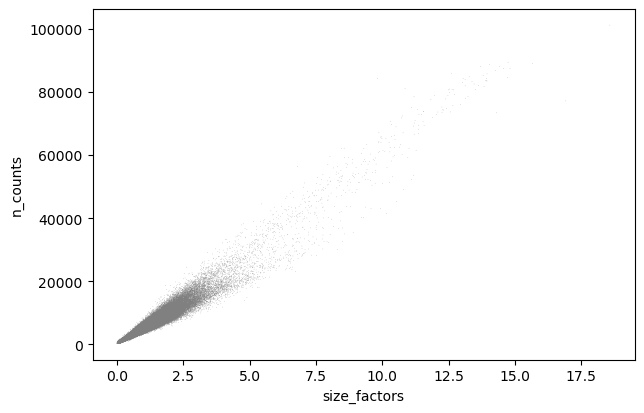

/scratch/23435308/ipykernel_87233/1875338984.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)


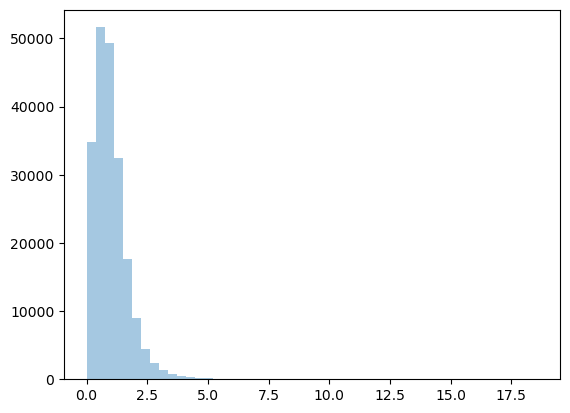

In [27]:
# Visualize the estimated size factors
adatas[0].obs['size_factors'] = size_factors.obs['sizeFactor'].values[:,None]

sc.pl.scatter(adatas[0], 'size_factors', 'n_counts')

sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)
plt.show()

Median total count of UMI is: 5125.0


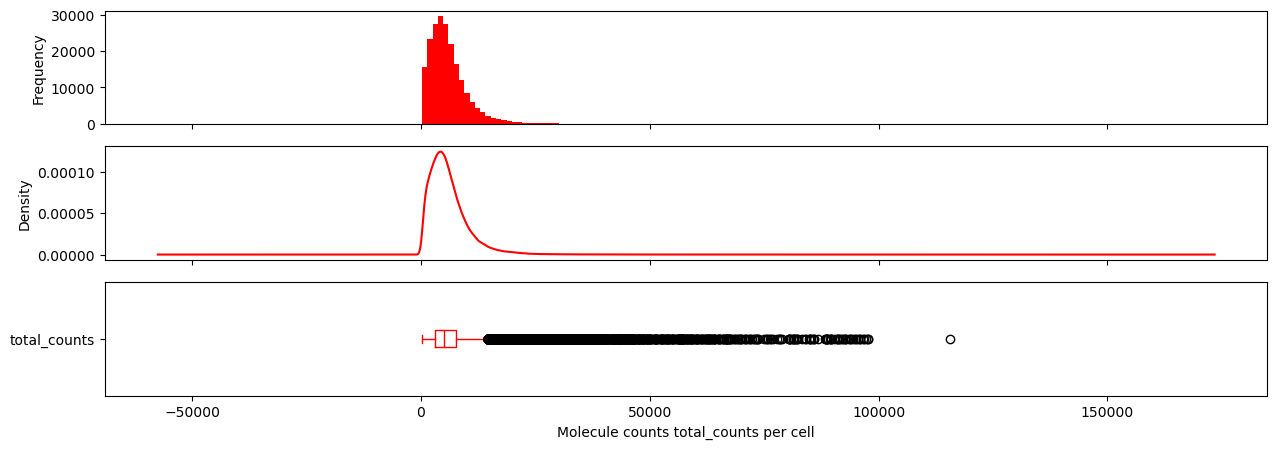

In [28]:
total_molecules_per_cell(adatas[0], count="total_counts")

In [29]:
tmp = adatas[0].X / adatas[0].obs["size_factors"].values[:, None]
mtx = csr_matrix(sc.pp.log1p(tmp))
adata_scr = sc.AnnData(X=mtx,
                       obs={'obs_names': adatas[0].obs_names},
                       var={'var_names': adatas[0].var_names})
adata_scr

/scratch/23435308/ipykernel_87233/1554638232.py:3: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_scr = sc.AnnData(X=mtx,


AnnData object with n_obs × n_vars = 205805 × 19248

Median total count of UMI is: 4363.356


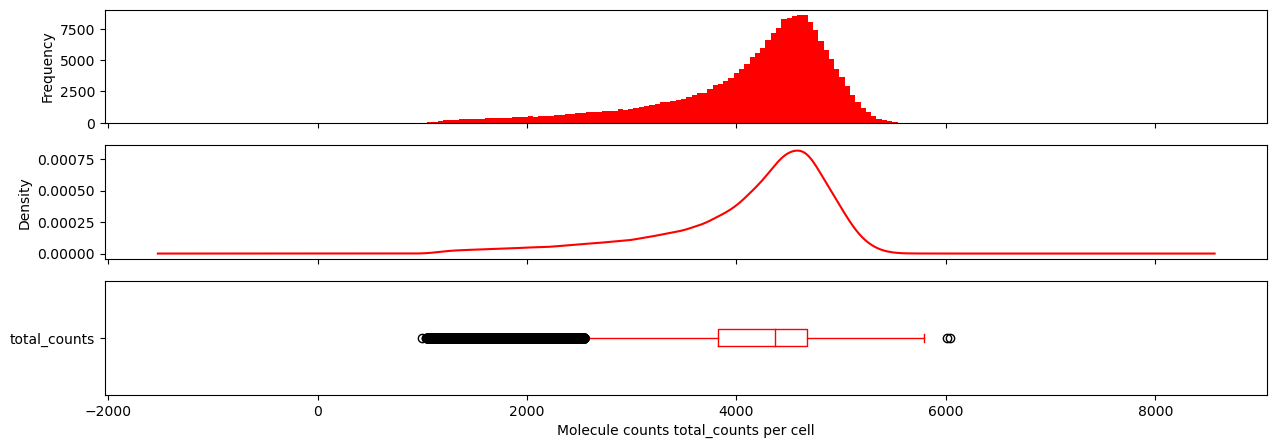

In [30]:
sc.pp.calculate_qc_metrics(adata_scr,
                           expr_type="counts",
                           var_type="genes",
                           inplace=True)

total_molecules_per_cell(adata_scr, count="total_counts")

In [ ]:
del adata_scr
del mtx
del tmp

### SMART-seq2 datasets are kept as is (Filbin2018 & Liu2022)

In [ ]:
# Set size factor to 1 for TPM values
adatas[1].obs['size_factors'] = 1
adatas[2].obs['size_factors'] = 1

Median total count of UMI is: 1000000.0


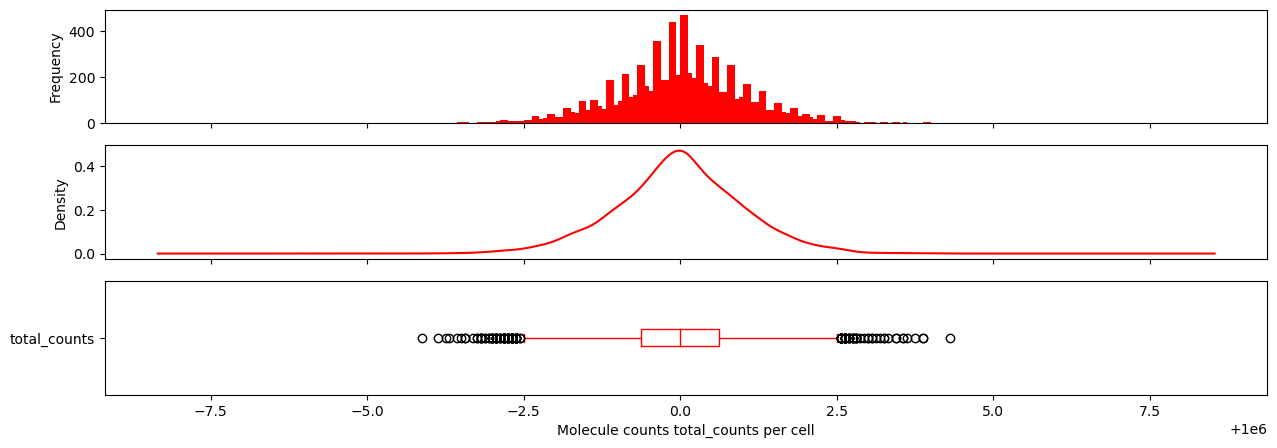

In [ ]:
total_molecules_per_cell(adatas[1], count="total_counts")

Median total count of UMI is: 829855.56


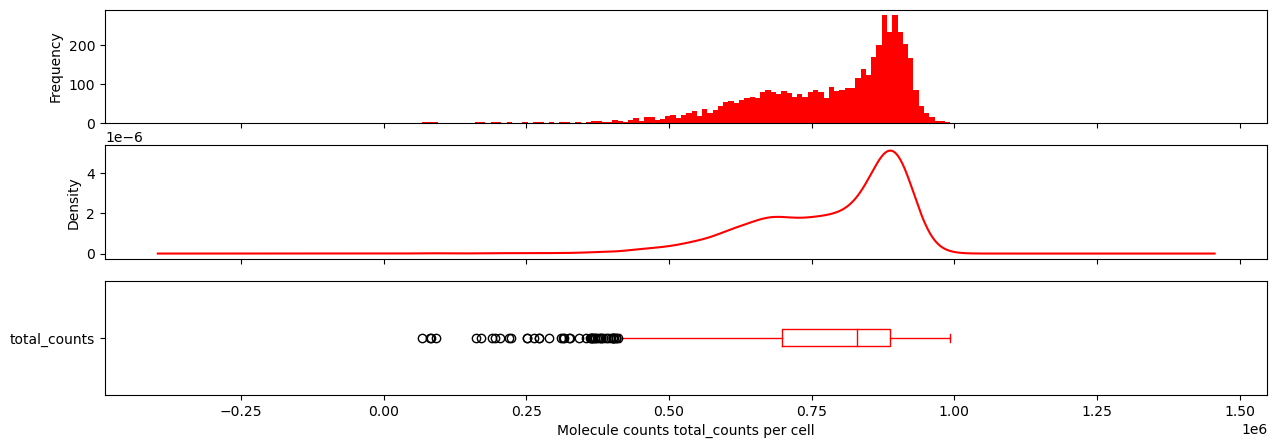

In [ ]:
total_molecules_per_cell(adatas[2], count="total_counts")

### 10Xv3_cell_rna (Jessa2022) scran normalization

In [ ]:
#Preprocess variables for scran normalization
input_groups = adatas[3].obs['groups']
data_mat = adata[adata.obs['Batch_for_correction']==protocol_id[3]].X.T

In [ ]:
%%R -i data_mat -i input_groups -o size_factors

# adapted from
# https://github.com/LungCellAtlas/HLCA_reproducibility/blob/main/scripts/scib_excerpts.py

size_factors = computeSumFactors(SingleCellExperiment(list(counts=data_mat)), # needs to be sce object
                                 # https://github.com/theislab/scib/issues/141
                                 clusters=input_groups, 
                                 min.mean=0.1)

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.py:106: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  return AnnData(exprs, obs, var, uns, obsm or None, layers=layers)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.p

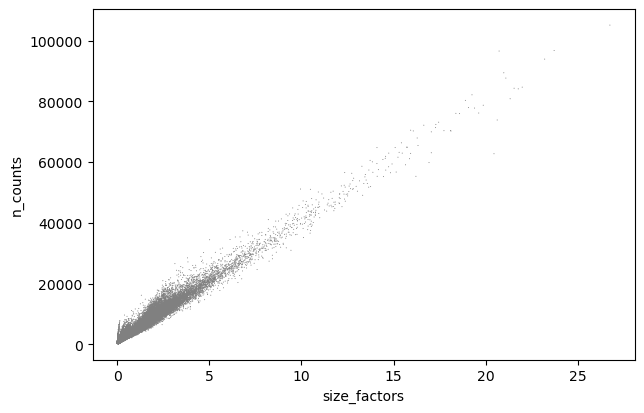

/scratch/23435308/ipykernel_87233/339869713.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)


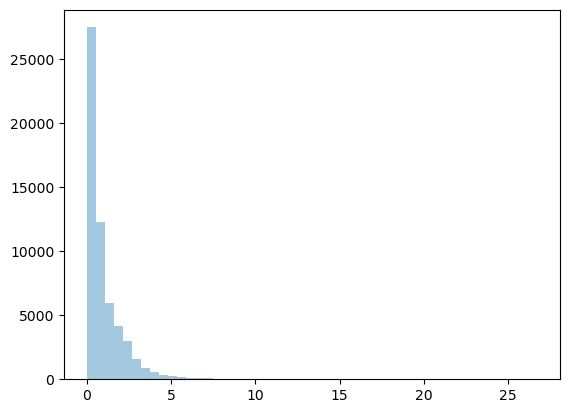

In [ ]:
# Visualize the estimated size factors
adatas[3].obs['size_factors'] = size_factors.obs['sizeFactor'].values[:,None]

sc.pl.scatter(adatas[3], 'size_factors', 'n_counts')

sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)
plt.show()

Median total count of UMI is: 3149.0


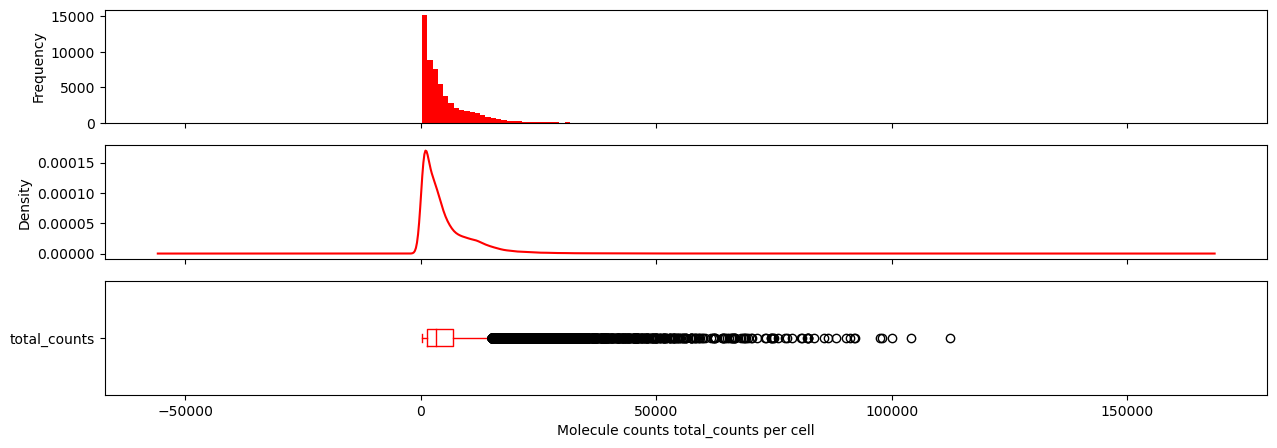

In [ ]:
total_molecules_per_cell(adatas[3], count="total_counts")

In [ ]:
tmp = adatas[3].X / adatas[3].obs["size_factors"].values[:, None]
mtx = csr_matrix(sc.pp.log1p(tmp))
adata_scr = sc.AnnData(X=mtx,
                       obs={'obs_names': adatas[3].obs_names},
                       var={'var_names': adatas[3].var_names})
adata_scr

/scratch/23435308/ipykernel_87233/4188422072.py:3: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_scr = sc.AnnData(X=mtx,


AnnData object with n_obs × n_vars = 57305 × 19248

Median total count of UMI is: 3783.0544


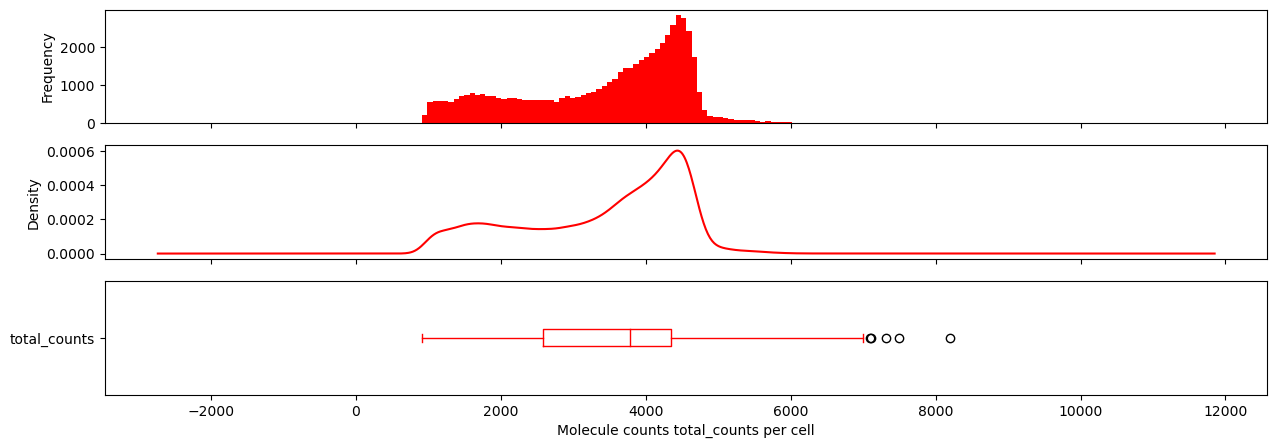

In [ ]:
sc.pp.calculate_qc_metrics(adata_scr,
                           expr_type="counts",
                           var_type="genes",
                           inplace=True)

total_molecules_per_cell(adata_scr, count="total_counts")

In [ ]:
del adata_scr
del mtx
del tmp

### 10Xv3_nuclei_rna (Jessa2022) scran normalization

In [ ]:
#Preprocess variables for scran normalization
input_groups = adatas[4].obs['groups']
data_mat = adata[adata.obs['Batch_for_correction']==protocol_id[4]].X.T

In [ ]:
%%R -i data_mat -i input_groups -o size_factors

# adapted from
# https://github.com/LungCellAtlas/HLCA_reproducibility/blob/main/scripts/scib_excerpts.py

size_factors = computeSumFactors(SingleCellExperiment(list(counts=data_mat)), # needs to be sce object
                                 # https://github.com/theislab/scib/issues/141
                                 clusters=input_groups, 
                                 min.mean=0.1)

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.py:106: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  return AnnData(exprs, obs, var, uns, obsm or None, layers=layers)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.p

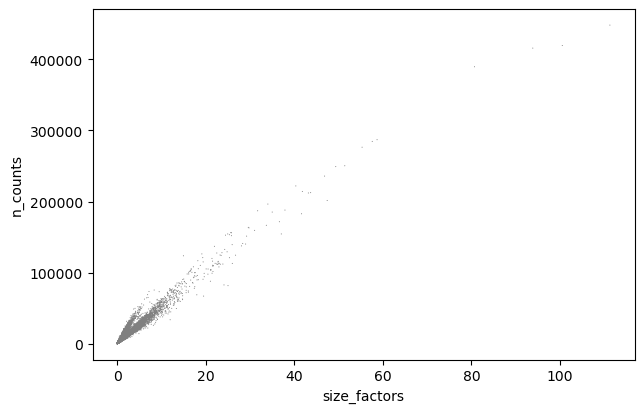

/scratch/23435308/ipykernel_87233/2647793018.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)


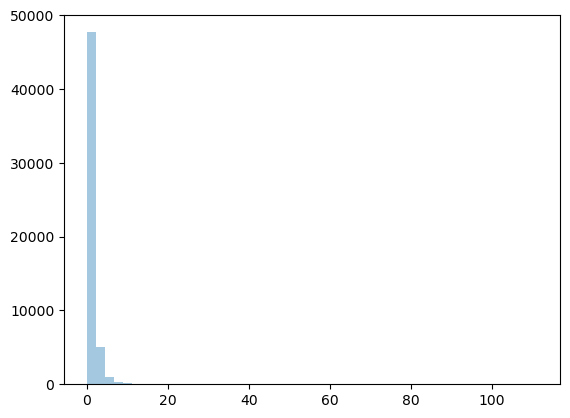

In [ ]:
# Visualize the estimated size factors
adatas[4].obs['size_factors'] = size_factors.obs['sizeFactor'].values[:,None]

sc.pl.scatter(adatas[4], 'size_factors', 'n_counts')

sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)
plt.show()

Median total count of UMI is: 1957.0


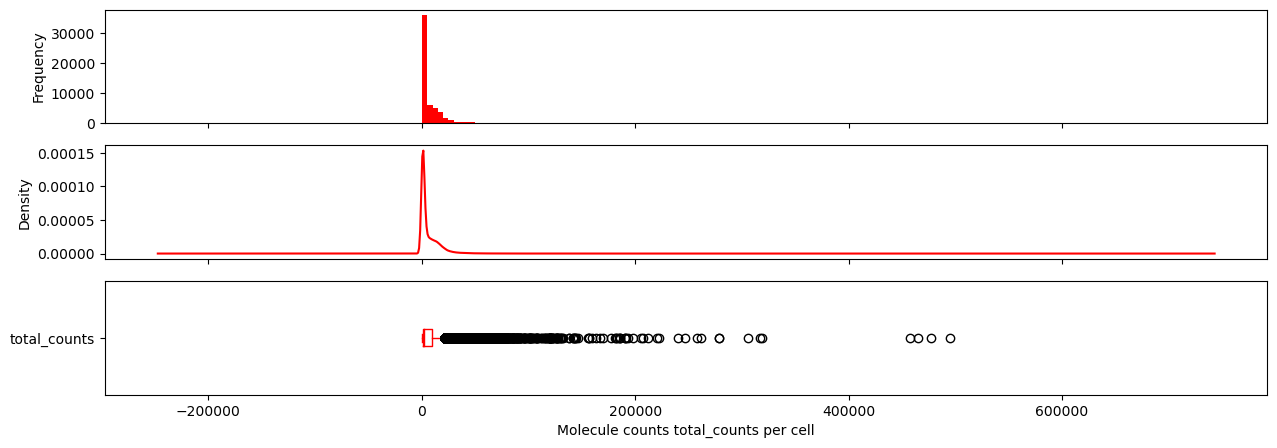

In [ ]:
total_molecules_per_cell(adatas[4], count="total_counts")

In [ ]:
tmp = adatas[4].X / adatas[4].obs["size_factors"].values[:, None]
mtx = csr_matrix(sc.pp.log1p(tmp))
adata_scr = sc.AnnData(X=mtx,
                       obs={'obs_names': adatas[4].obs_names},
                       var={'var_names': adatas[4].var_names})
adata_scr

/scratch/23435308/ipykernel_87233/858361253.py:3: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_scr = sc.AnnData(X=mtx,


AnnData object with n_obs × n_vars = 54529 × 19248

Median total count of UMI is: 3442.7085


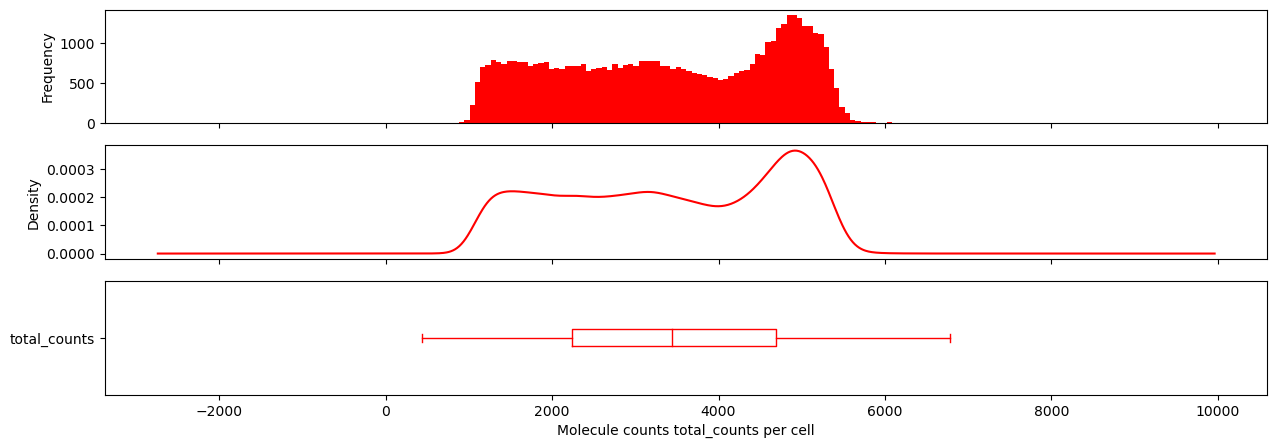

In [ ]:
sc.pp.calculate_qc_metrics(adata_scr,
                           expr_type="counts",
                           var_type="genes",
                           inplace=True)

total_molecules_per_cell(adata_scr, count="total_counts")

In [ ]:
del adata_scr
del mtx
del tmp

### 10Xv1_nuclei_multiome (Jessa2022) scran normalization

In [ ]:
#Preprocess variables for scran normalization
input_groups = adatas[5].obs['groups']
data_mat = adata[adata.obs['Batch_for_correction']==protocol_id[5]].X.T

In [ ]:
%%R -i data_mat -i input_groups -o size_factors

# adapted from
# https://github.com/LungCellAtlas/HLCA_reproducibility/blob/main/scripts/scib_excerpts.py

size_factors = computeSumFactors(SingleCellExperiment(list(counts=data_mat)), # needs to be sce object
                                 # https://github.com/theislab/scib/issues/141
                                 clusters=input_groups, 
                                 min.mean=0.1)

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.py:106: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  return AnnData(exprs, obs, var, uns, obsm or None, layers=layers)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata2ri/r2py.p

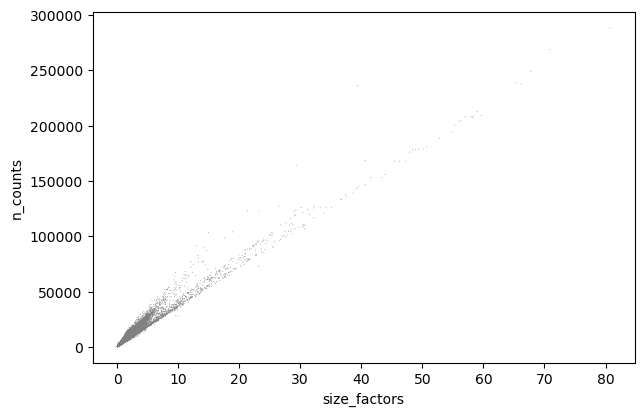

/scratch/23435308/ipykernel_87233/386359824.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)


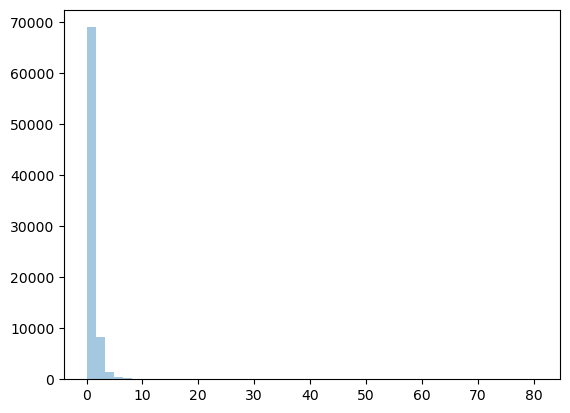

In [ ]:
# Visualize the estimated size factors
adatas[5].obs['size_factors'] = size_factors.obs['sizeFactor'].values[:,None]

sc.pl.scatter(adatas[5], 'size_factors', 'n_counts')

sb.distplot(size_factors.obs['sizeFactor'].values[:,None], bins=50, kde=False)
plt.show()

Median total count of UMI is: 3467.0


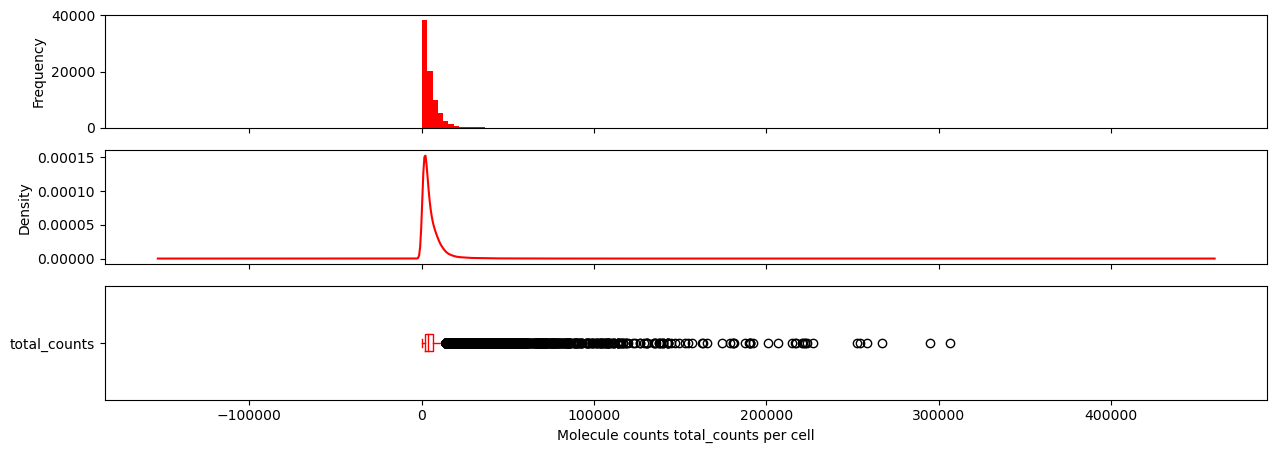

In [ ]:
total_molecules_per_cell(adatas[5], count="total_counts")

In [ ]:
tmp = adatas[5].X / adatas[5].obs["size_factors"].values[:, None]
mtx = csr_matrix(sc.pp.log1p(tmp))
adata_scr = sc.AnnData(X=mtx,
                       obs={'obs_names': adatas[5].obs_names},
                       var={'var_names': adatas[5].var_names})
adata_scr

/scratch/23435308/ipykernel_87233/3897263939.py:3: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata_scr = sc.AnnData(X=mtx,


AnnData object with n_obs × n_vars = 80155 × 19248

Median total count of UMI is: 4224.133


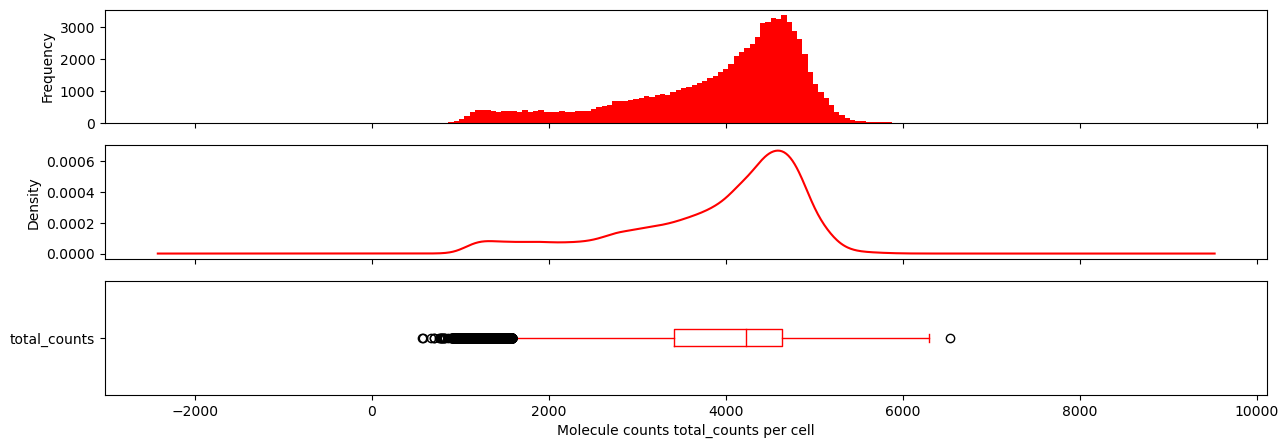

In [ ]:
sc.pp.calculate_qc_metrics(adata_scr,
                           expr_type="counts",
                           var_type="genes",
                           inplace=True)

total_molecules_per_cell(adata_scr, count="total_counts")

In [ ]:
del adata_scr
del mtx
del tmp

### Merge data

Now, let us concatenate all temporary anndata objects to one file in order to concatenate the size factors to one vector.

In [ ]:
adata_tmp = adatas[0].concatenate(adatas[1:])

/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],
/hpc/pmc_stunnenberg/cruiz/miniconda3/envs/r_python/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype be

Assign size factors to original data set collection.

In [ ]:
adata.obs['size_factors'] = adata_tmp.obs['size_factors'].values

Check size factor distribution.

/scratch/23435308/ipykernel_87233/809879014.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(adata.obs['size_factors'], bins=50, kde=False)


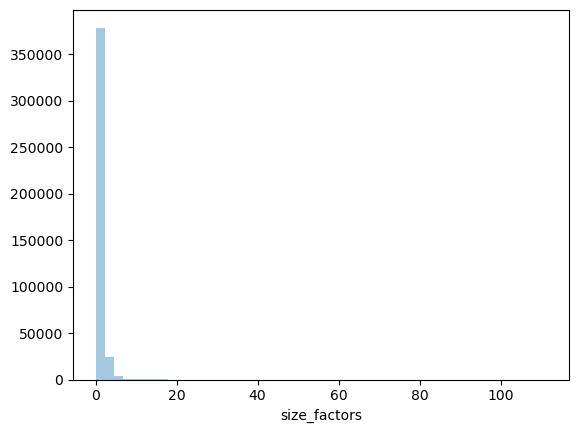

In [ ]:
sb.distplot(adata.obs['size_factors'], bins=50, kde=False)
plt.show()

In [23]:
# concatenation adds a hyphen plus number of the batch to each cell, so alters the normal cell ID
# to make sure the are in the same order we need to compare 
adata_tmp.obs_names = [name[:-2] for name in adata_tmp.obs_names]

In [22]:
# Check whether the cell order is the same between the two objects
same_order = all(adata.obs_names == adata_tmp.obs_names)

if same_order:
    print("The cell order is the same between the corrected and uncorrected data.")
else:
    print("The cell order is different between the corrected and uncorrected data.")

The cell order is the same between the corrected and uncorrected data.


In [16]:
# Check whether the cell order is the same between the two objects
same_order = all(adata.var_names == adata_tmp.var_names)

if same_order:
    print("The cell order is the same between the corrected and uncorrected data.")
else:
    print("The cell order is different between the corrected and uncorrected data.")

The cell order is the same between the corrected and uncorrected data.


Free memory.

In [ ]:
del adata_tmp
del adata_pp
del adatas

Finally, normalise data.

In [ ]:
#Normalize adata 
scran = adata.X / adata.obs["size_factors"].values[:, None]
adata.layers["scran_normalization"] = csr_matrix(sc.pp.log1p(scran))

# log1p proportional fitting

As explained here https://www.sc-best-practices.org/preprocessing_visualization/normalization.html#id133

In [ ]:
# proportional fitting to mean of cell depth
proportional_fitting = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1pPF_normalization"] = sc.pp.log1p(proportional_fitting["X"])
# proportional fitting
adata.layers["PFlog1pPF_normalization"] = sc.pp.normalize_total(
    adata, target_sum=None, layer="log1pPF_normalization", inplace=False
)["X"]

normalizing counts per cell
    finished (0:00:20)
normalizing counts per cell
    finished (0:00:22)


Save normalised data to file.

In [ ]:
sc.write(adata=adata, filename=path_dir + 'merged_dmg_atlas_qc_filtered_and_normalized.h5ad', 
        compression = 'gzip')